In [ ]:
# File paths
input_imzml_path = "/home/ajarrah/PhD_Thesis/250616_Vanderbilt_MSI/imzML data/3xtg_aged_ad_4_3.imzML"
output_h5ad_path = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_raw/3xtg_aged_ad_4_3.h5ad"

#parameters
sample_number="4-3"
batch_number ="Slide_4"
age_group="Aged"
disease_status="AD"
image_size_cm = 20.0
image_resolution = 0.001  # cm per pixel
batch_size=5000

In [252]:
import numpy as np
from pyimzml.ImzMLParser import ImzMLParser

class UniversalImzMLReader:
    def __init__(self, imzml_path: str):
        """
        Universal reader for imzML files using pyimzml.
        Automatically handles compressed and uncompressed datasets.
        
        Parameters
        ----------
        imzml_path : str
            Path to the .imzML file (the .ibd must be in the same directory).
        """
        self.parser = ImzMLParser(imzml_path)

        # Store spectra metadata (index, x, y)
        self.spectra_meta = []
        for idx, (x, y, z) in enumerate(self.parser.coordinates):
            self.spectra_meta.append({
                "index": idx,
                "x": x,
                "y": y
            })

    def getspectrum(self, index: int):
        """
        Return the m/z and intensity arrays for the given spectrum index.
        Always returns numpy arrays with dtype float64.
        """
        mzs, intensities = self.parser.getspectrum(index)
        return np.array(mzs, dtype=np.float64), np.array(intensities, dtype=np.float64)

    def unique_mzs(self):
        """
        Collect all unique m/z values from the dataset.
        This may be slow for large files — consider binning instead.
        """
        mzs_all = []
        for idx in range(len(self.parser.coordinates)):
            mzs, _ = self.parser.getspectrum(idx)
            mzs_all.extend(mzs)
        return np.unique(np.array(mzs_all, dtype=np.float64))


In [253]:
import numpy as np
import scanpy as sc
from scipy.sparse import csr_matrix

def setup_spatial_data(adata, image_size_cm, image_resolution):
    """
    Sets up a blank spatial dictionary for visualization.
    """
    img_size_px = int(image_size_cm / image_resolution)  # Convert cm to pixels
    blank_image = np.zeros((img_size_px, img_size_px, 3), dtype=np.uint8)

    adata.uns['spatial'] = {
        'spatial': {
            'scalefactors': {
                'tissue_hires_scalef': 1.0,
                'spot_diameter_fullres': 0.05  # arbitrary value
            },
            'images': {
                'hires': blank_image,
                'lowres': blank_image
            }
        }
    }

    if 'x' not in adata.obs or 'y' not in adata.obs:
        raise ValueError("adata.obs must contain 'x' and 'y' coordinates.")

    print("Spatial data setup complete.")
    return adata


def build_anndata_from_reader(
    reader,
    sample_num: str,
    batch_num: str,
    age_group: str,
    disease_status: str,
    image_size_cm: float = 1.0,
    image_resolution: float = 0.01,  # cm per pixel
    batch_size: int = 500
):

    n_spectra = len(reader.spectra_meta)
    print(f"Total spectra: {n_spectra}")

    # Collect global unique m/z values
    print("Collecting global unique m/z values (this may take a while)...")
    global_mzs = reader.unique_mzs()
    global_mzs = np.array(sorted(set(np.round(global_mzs, 6))))  # consistent precision
    print(f"Found {len(global_mzs)} unique m/z values in dataset.")

    mz_to_idx = {mz: i for i, mz in enumerate(global_mzs)}

    rows, cols, vals = [], [], []
    coords = []

    for start in range(0, n_spectra, batch_size):
        end = min(start + batch_size, n_spectra)
        for i in range(start, end):
            mzs, intensities = reader.getspectrum(i)
            coords.append((reader.spectra_meta[i]["x"], reader.spectra_meta[i]["y"]))
            if mzs.size == 0:
                continue
            valid = intensities != 0
            mzs, intensities = mzs[valid], intensities[valid]

            for mz, inten in zip(mzs, intensities):
                idx = mz_to_idx.get(round(mz, 6))
                if idx is not None:
                    rows.append(i)
                    cols.append(idx)
                    vals.append(float(inten))

        print(f"Processed spectra {start} to {end}...")

    # Create sparse matrix
    X = csr_matrix((vals, (rows, cols)), shape=(n_spectra, len(global_mzs)))

    # Prepare AnnData object
    adata = sc.AnnData(X=X)

    coords_array = np.array(coords)
    
    # --- Normalize coordinates ---
    min_x, min_y = coords_array[:, 0].min(), coords_array[:, 1].min()
    norm_x = coords_array[:, 0] - min_x
    norm_y = coords_array[:, 1] - min_y
    adata.obs["x"] = norm_x
    adata.obs["y"] = norm_y

    # Add m/z info to var
    adata.var["mzs"] = global_mzs

    # Normalize by TIC (total ion current)
    tic = np.array(X.sum(axis=1)).flatten()
    adata.obs["TIC"] = tic
    tic_nonzero = tic.copy()
    tic_nonzero[tic_nonzero == 0] = 1  # avoid div by zero
    norm_matrix = X.multiply(1 / tic_nonzero[:, None])
    adata.layers["tic_normalized"] = csr_matrix(norm_matrix)

    # Add metadata columns
    adata.obs["sample"] = [sample_num] * adata.n_obs
    adata.obs["batch"] = [batch_num] * adata.n_obs
    adata.obs["age_group"] = [age_group] * adata.n_obs
    adata.obs["disease_status"] = [disease_status] * adata.n_obs

    # Store raw copy
    adata.raw = adata.copy()

    # Setup spatial dictionary for visualization
    adata = setup_spatial_data(adata, image_size_cm, image_resolution)

    print("AnnData object created with shape:", adata.shape)
    return adata

In [254]:
reader = UniversalImzMLReader(input_imzml_path)

adata = build_anndata_from_reader(
    reader,
    sample_num=sample_number,
    batch_num=batch_number,
    age_group=age_group,
    disease_status=disease_status,
    image_size_cm = image_size_cm,
    image_resolution = image_resolution,  # cm per pixel
    batch_size=batch_size
)

/opt/anaconda3/lib/python3.12/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


Total spectra: 14410
Found 292322 unique m/z values in dataset.
Processed spectra 0 to 5000...
Processed spectra 5000 to 10000...
Processed spectra 10000 to 14410...
Spatial data setup complete.
AnnData object created with shape: (14410, 292322)


In [255]:
adata

AnnData object with n_obs × n_vars = 14410 × 292322
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status'
    var: 'mzs'
    uns: 'spatial'
    layers: 'tic_normalized'

In [256]:
adata.var.index = list(adata.var['mzs'])
adata.var

,mzs
300.0000,300.0000
300.0015,300.0015
300.0030,300.0030
300.0045,300.0045
300.0060,300.0060
...,...
1299.9740,1299.9740
1299.9805,1299.9805
1299.9870,1299.9870
1299.9935,1299.9935


In [257]:
adata.obs

,x,y,TIC,sample,batch,age_group,disease_status
0,20,0,5.893188e+06,4-3,Slide_4,Aged,AD
1,21,0,5.926269e+06,4-3,Slide_4,Aged,AD
2,22,0,5.854745e+06,4-3,Slide_4,Aged,AD
3,23,0,5.832276e+06,4-3,Slide_4,Aged,AD
4,24,0,5.841986e+06,4-3,Slide_4,Aged,AD
...,...,...,...,...,...,...,...
14405,56,100,5.275681e+06,4-3,Slide_4,Aged,AD
14406,57,100,5.291098e+06,4-3,Slide_4,Aged,AD
14407,58,100,5.305095e+06,4-3,Slide_4,Aged,AD
14408,59,100,5.249392e+06,4-3,Slide_4,Aged,AD


In [258]:
print(f"{adata}: Matrix shape = {adata.X.shape}, Non-zero elements = {adata.X.nnz if hasattr(adata.X, 'nnz') else 'N/A'}")

AnnData object with n_obs × n_vars = 14410 × 292322
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status'
    var: 'mzs'
    uns: 'spatial'
    layers: 'tic_normalized': Matrix shape = (14410, 292322), Non-zero elements = 100793958


In [259]:
adata.write(output_h5ad_path)

In [260]:
import matplotlib.pyplot as plt
import squidpy as sq

def plot_mz_image(adata, mz_value):
    # Find the index of the m/z value closest to the requested mz_value
    mz_index = np.argmin(np.abs(adata.var['mzs'].values - mz_value))

    # Extract the intensity values for the specified m/z
    intensities = adata.X[:, mz_index].toarray().flatten()

    # Extract the x and y coordinates of each spot
    x_coords = adata.obs['x'].values
    y_coords = adata.obs['y'].values

    # Create scatter plot, where spot color represents intensity for the given m/z
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(x_coords, y_coords, c=intensities, cmap='viridis', s=35, edgecolor='none')
    
    # Add color bar and labels
    plt.colorbar(scatter, label=f'Intensity bar at m/z = {mz_value}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'Intensity Map for m/z = {mz_value}')
    plt.gca().invert_yaxis()  # Invert y-axis for proper spatial representation

    # Display the plot
    plt.show()

In [261]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix

def plot_normalized_mz_image(adata, mz_value):
    """
    Plot a TIC-normalized intensity map for a given m/z value from an AnnData object.
    Works even if tic_normalized is stored as a COO sparse matrix.
    """
    # Step 1: Find the index of the m/z value closest to the requested mz_value
    mz_index = np.argmin(np.abs(adata.var['mzs'].values - mz_value))

    # Step 2: Convert COO to CSR for efficient slicing
    X = adata.layers['tic_normalized']
    if isinstance(X, coo_matrix):
        X = X.tocsr()

    # Step 3: Extract normalized intensities for the specified m/z
    normalized_intensities = X[:, mz_index].toarray().flatten()

    # Step 4: Extract coordinates
    x_coords = adata.obs['x'].values
    y_coords = adata.obs['y'].values

    # Step 5: Create scatter plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        x_coords,
        y_coords,
        c=normalized_intensities,
        cmap='viridis',
        s=35,
        edgecolor='none'
    )

    # Step 6: Add labels
    plt.colorbar(scatter, label=f'Normalized Intensity at m/z = {mz_value:.4f}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'Normalized Intensity Map for m/z = {mz_value:.4f}')
    plt.gca().invert_yaxis()
    plt.show()

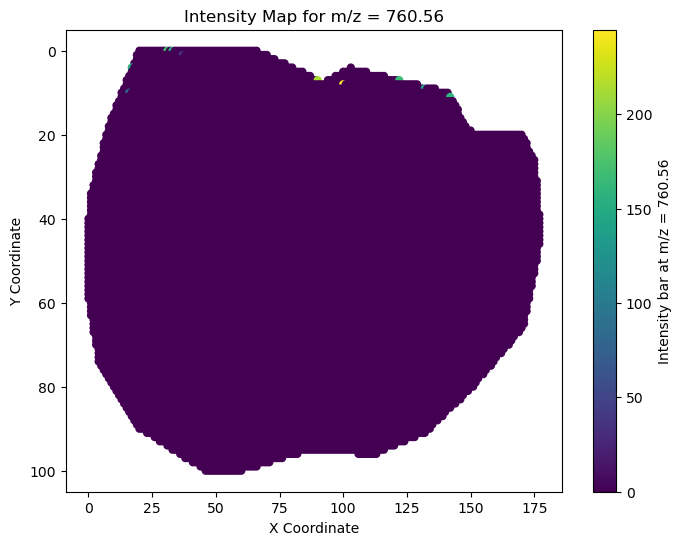

In [262]:
plot_mz_image(adata,760.56)

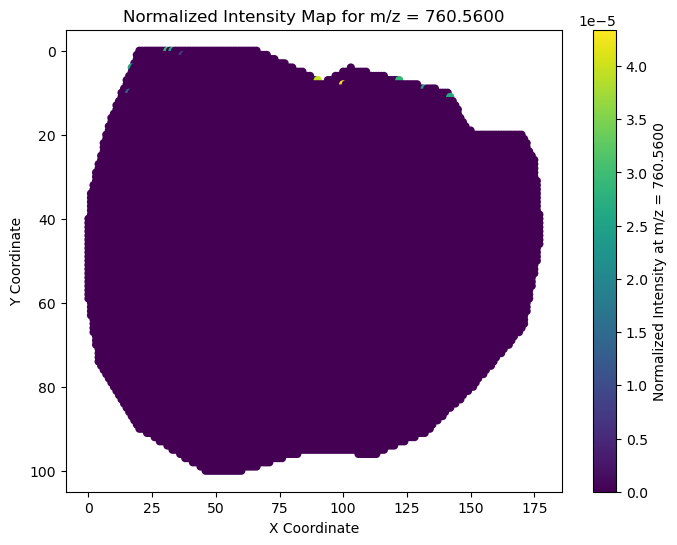

In [263]:
plot_normalized_mz_image(adata, mz_value=760.56)

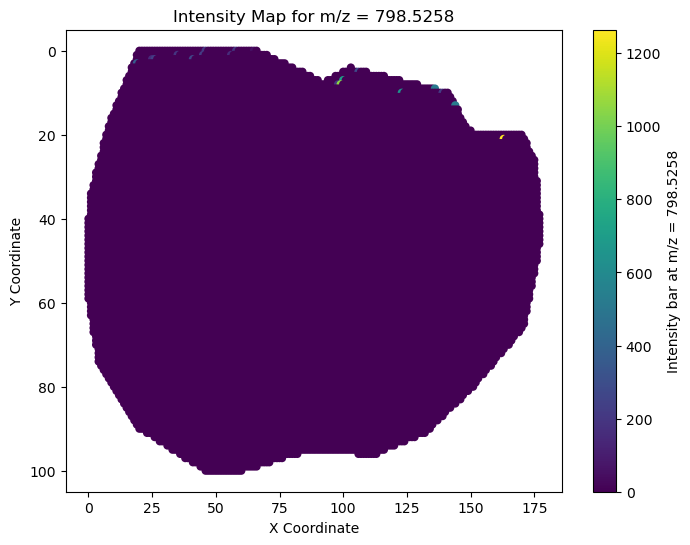

In [264]:
plot_mz_image(adata, mz_value=798.5258)

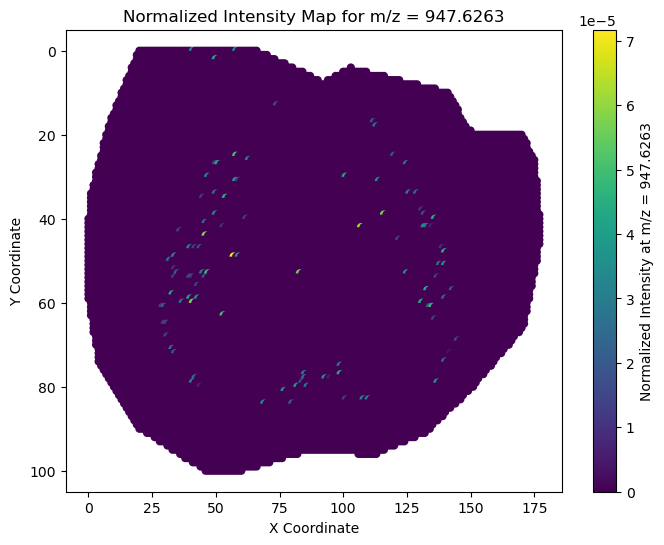

In [265]:
plot_normalized_mz_image(adata, mz_value=947.6263)